In [1]:
# Demo file for working with univariate data
# live entstanden in der Vorlesung GIB Mathematik2, 18.03.2026
#
# copyright: Barbara Staehle, HTWG Konstanz
# bstaehle@htwg-konstanz.de

# import library we use for plotting and calculating
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as stat

In [2]:
# read data from excelfile
# for excel-file, see Moodle!
umfrage = pd.read_excel('../../data/zehn_Fragen_ss26_clean.xlsx')
# Daten ausgeben
#print(umfrage)

In [3]:
data = umfrage['Q05_Stochastik-Vorwissen']
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q05_Stochastik-Vorwissen'] # 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q05_Stochastik-Vorwissen'] # 

In [4]:
print(f'empirische Standardabweichung für AIN+GIB: {np.std(data,ddof=1):.3f}')
print(f'empirische Standardabweichung für AIN: {np.std(ain_data,ddof=1):.3f}')
print(f'empirische Standardabweichung für GIB: {np.std(gib_data,ddof=1):.3f}')

empirische Standardabweichung für AIN+GIB: 2.255
empirische Standardabweichung für AIN: 2.530
empirische Standardabweichung für GIB: 2.054


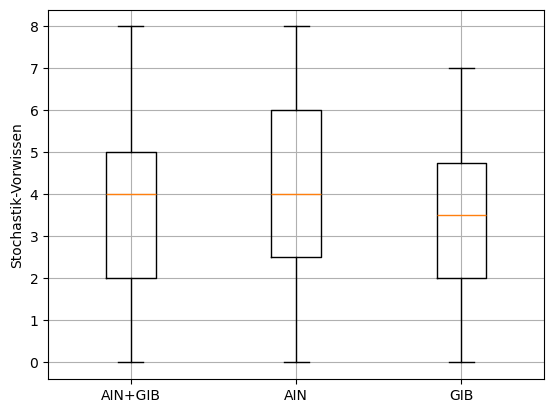

In [5]:
# Boxplot, zum Vergleich des Wissens der Studierenden
plt.boxplot([data,ain_data,gib_data])
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
#plt.xlabel('Studiengang')
plt.ylabel('Stochastik-Vorwissen')
plt.show()

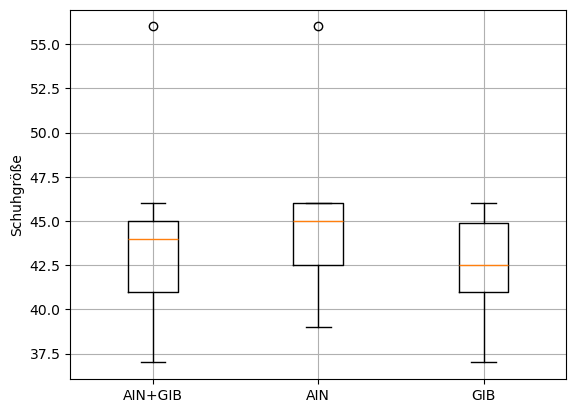

In [6]:
# Boxplot, zum Vergleich der Schuhgröße der Studierenden
data = umfrage['Q02_Schuhgröße']
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q02_Schuhgröße'] # 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q02_Schuhgröße'] # 

plt.boxplot([data,ain_data,gib_data])
#plt.boxplot(data)
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
plt.ylabel('Schuhgröße')
plt.show() 

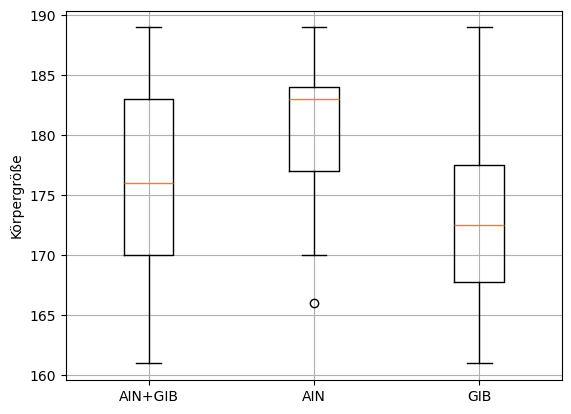

In [7]:
# Boxplot, zum Vergleich der Größe der Studierenden
data = umfrage['Q01_Körpergröße'] 
gib_data = umfrage[umfrage['Kurs'].str.contains('Mathematik', case=False, na=False)]['Q01_Körpergröße'] 
ain_data = umfrage[umfrage['Kurs'].str.contains('Stochastik', case=False, na=False)]['Q01_Körpergröße'] 

plt.boxplot([data,ain_data,gib_data])
plt.grid(True)
plt.xticks([1, 2,3], ['AIN+GIB','AIN','GIB'])
plt.ylabel('Körpergröße')
plt.show() 

In [9]:
# nur die quantitativen Merkmale (Zahlen) der Umfrage
numvals = umfrage.drop(columns=umfrage.columns[:4])
numvals = numvals.drop(columns=numvals.columns[3])
numvals = numvals.drop(columns=numvals.columns[6])

print(numvals)

    Q01_Körpergröße  Q02_Schuhgröße  Q03_Welches Semester  \
0               170            41.0                     4   
1               161            38.0                     2   
2               173            41.0                     4   
3               176            45.0                     2   
4               172            44.0                     2   
5               189            46.0                     2   
6               167            41.0                     2   
7               173            44.5                     2   
8               176            43.0                     3   
9               187            46.0                     4   
10              183            56.0                     3   
11              178            42.0                     3   
12              166            39.0                     3   
13              183            45.0                     3   
14              170            39.0                     3   
15              185     

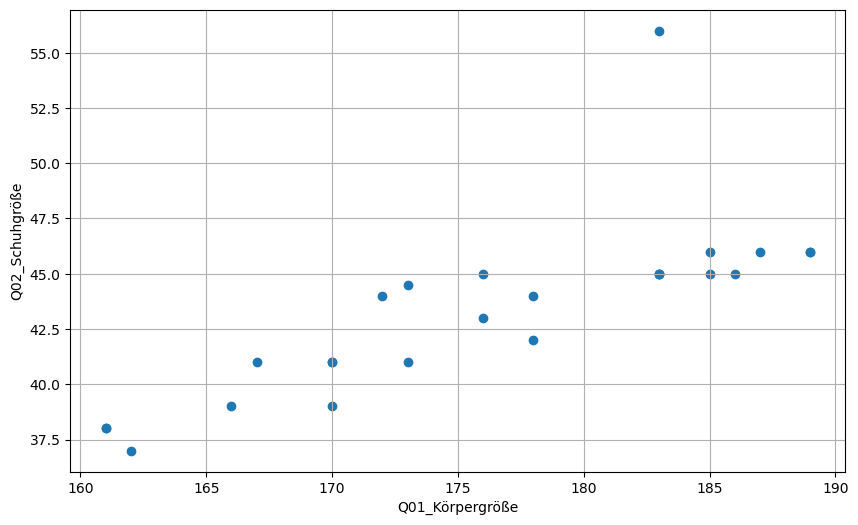

In [10]:
# Scatterplot Körpergröße vs. Schuhgröße
plt.figure(figsize=(10, 6))
plt.scatter(numvals['Q01_Körpergröße'], numvals['Q02_Schuhgröße'])
plt.grid(True)
plt.xlabel('Q01_Körpergröße')
plt.ylabel('Q02_Schuhgröße')
plt.show()

In [11]:
# Korrelationskoeffizient mit pandas
correlation = numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']].corr()
print(correlation)

                 Q01_Körpergröße  Q02_Schuhgröße
Q01_Körpergröße         1.000000        0.774626
Q02_Schuhgröße          0.774626        1.000000


In [12]:
print('Korrelation', correlation.iloc[0,1])

Korrelation 0.7746264089385602


In [13]:
# Korrelationskoeffizient mit numpy
np.corrcoef(numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']],rowvar=False)

array([[1.        , 0.77462641],
       [0.77462641, 1.        ]])

In [14]:
# Korrelationskoeffizienten für alle Daten
corrmatrix = numvals.corr()
print(corrmatrix)

                                Q01_Körpergröße  Q02_Schuhgröße  \
Q01_Körpergröße                        1.000000        0.774626   
Q02_Schuhgröße                         0.774626        1.000000   
Q03_Welches Semester                   0.150736        0.066585   
Q05_Stochastik-Vorwissen              -0.072006        0.007099   
Q06_Wie viele Jahre Mathematik        -0.151836        0.014946   
Q07_Geburtsjahr                        0.067591        0.001212   
Q09_Wie viel Wasser Training          -0.026613        0.092700   
Q10_Wie viel Wasser Antwort           -0.210248       -0.286552   

                                Q03_Welches Semester  \
Q01_Körpergröße                             0.150736   
Q02_Schuhgröße                              0.066585   
Q03_Welches Semester                        1.000000   
Q05_Stochastik-Vorwissen                    0.030086   
Q06_Wie viele Jahre Mathematik             -0.063586   
Q07_Geburtsjahr                            -0.190085   
Q09_

<Axes: >

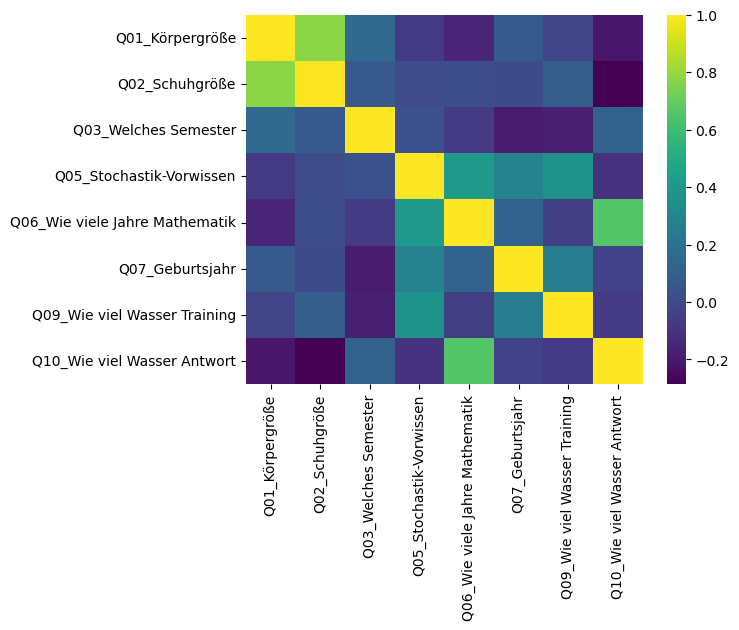

In [16]:
# als heatmap darstellen
import seaborn as sns
sns.heatmap(corrmatrix,cmap='viridis')

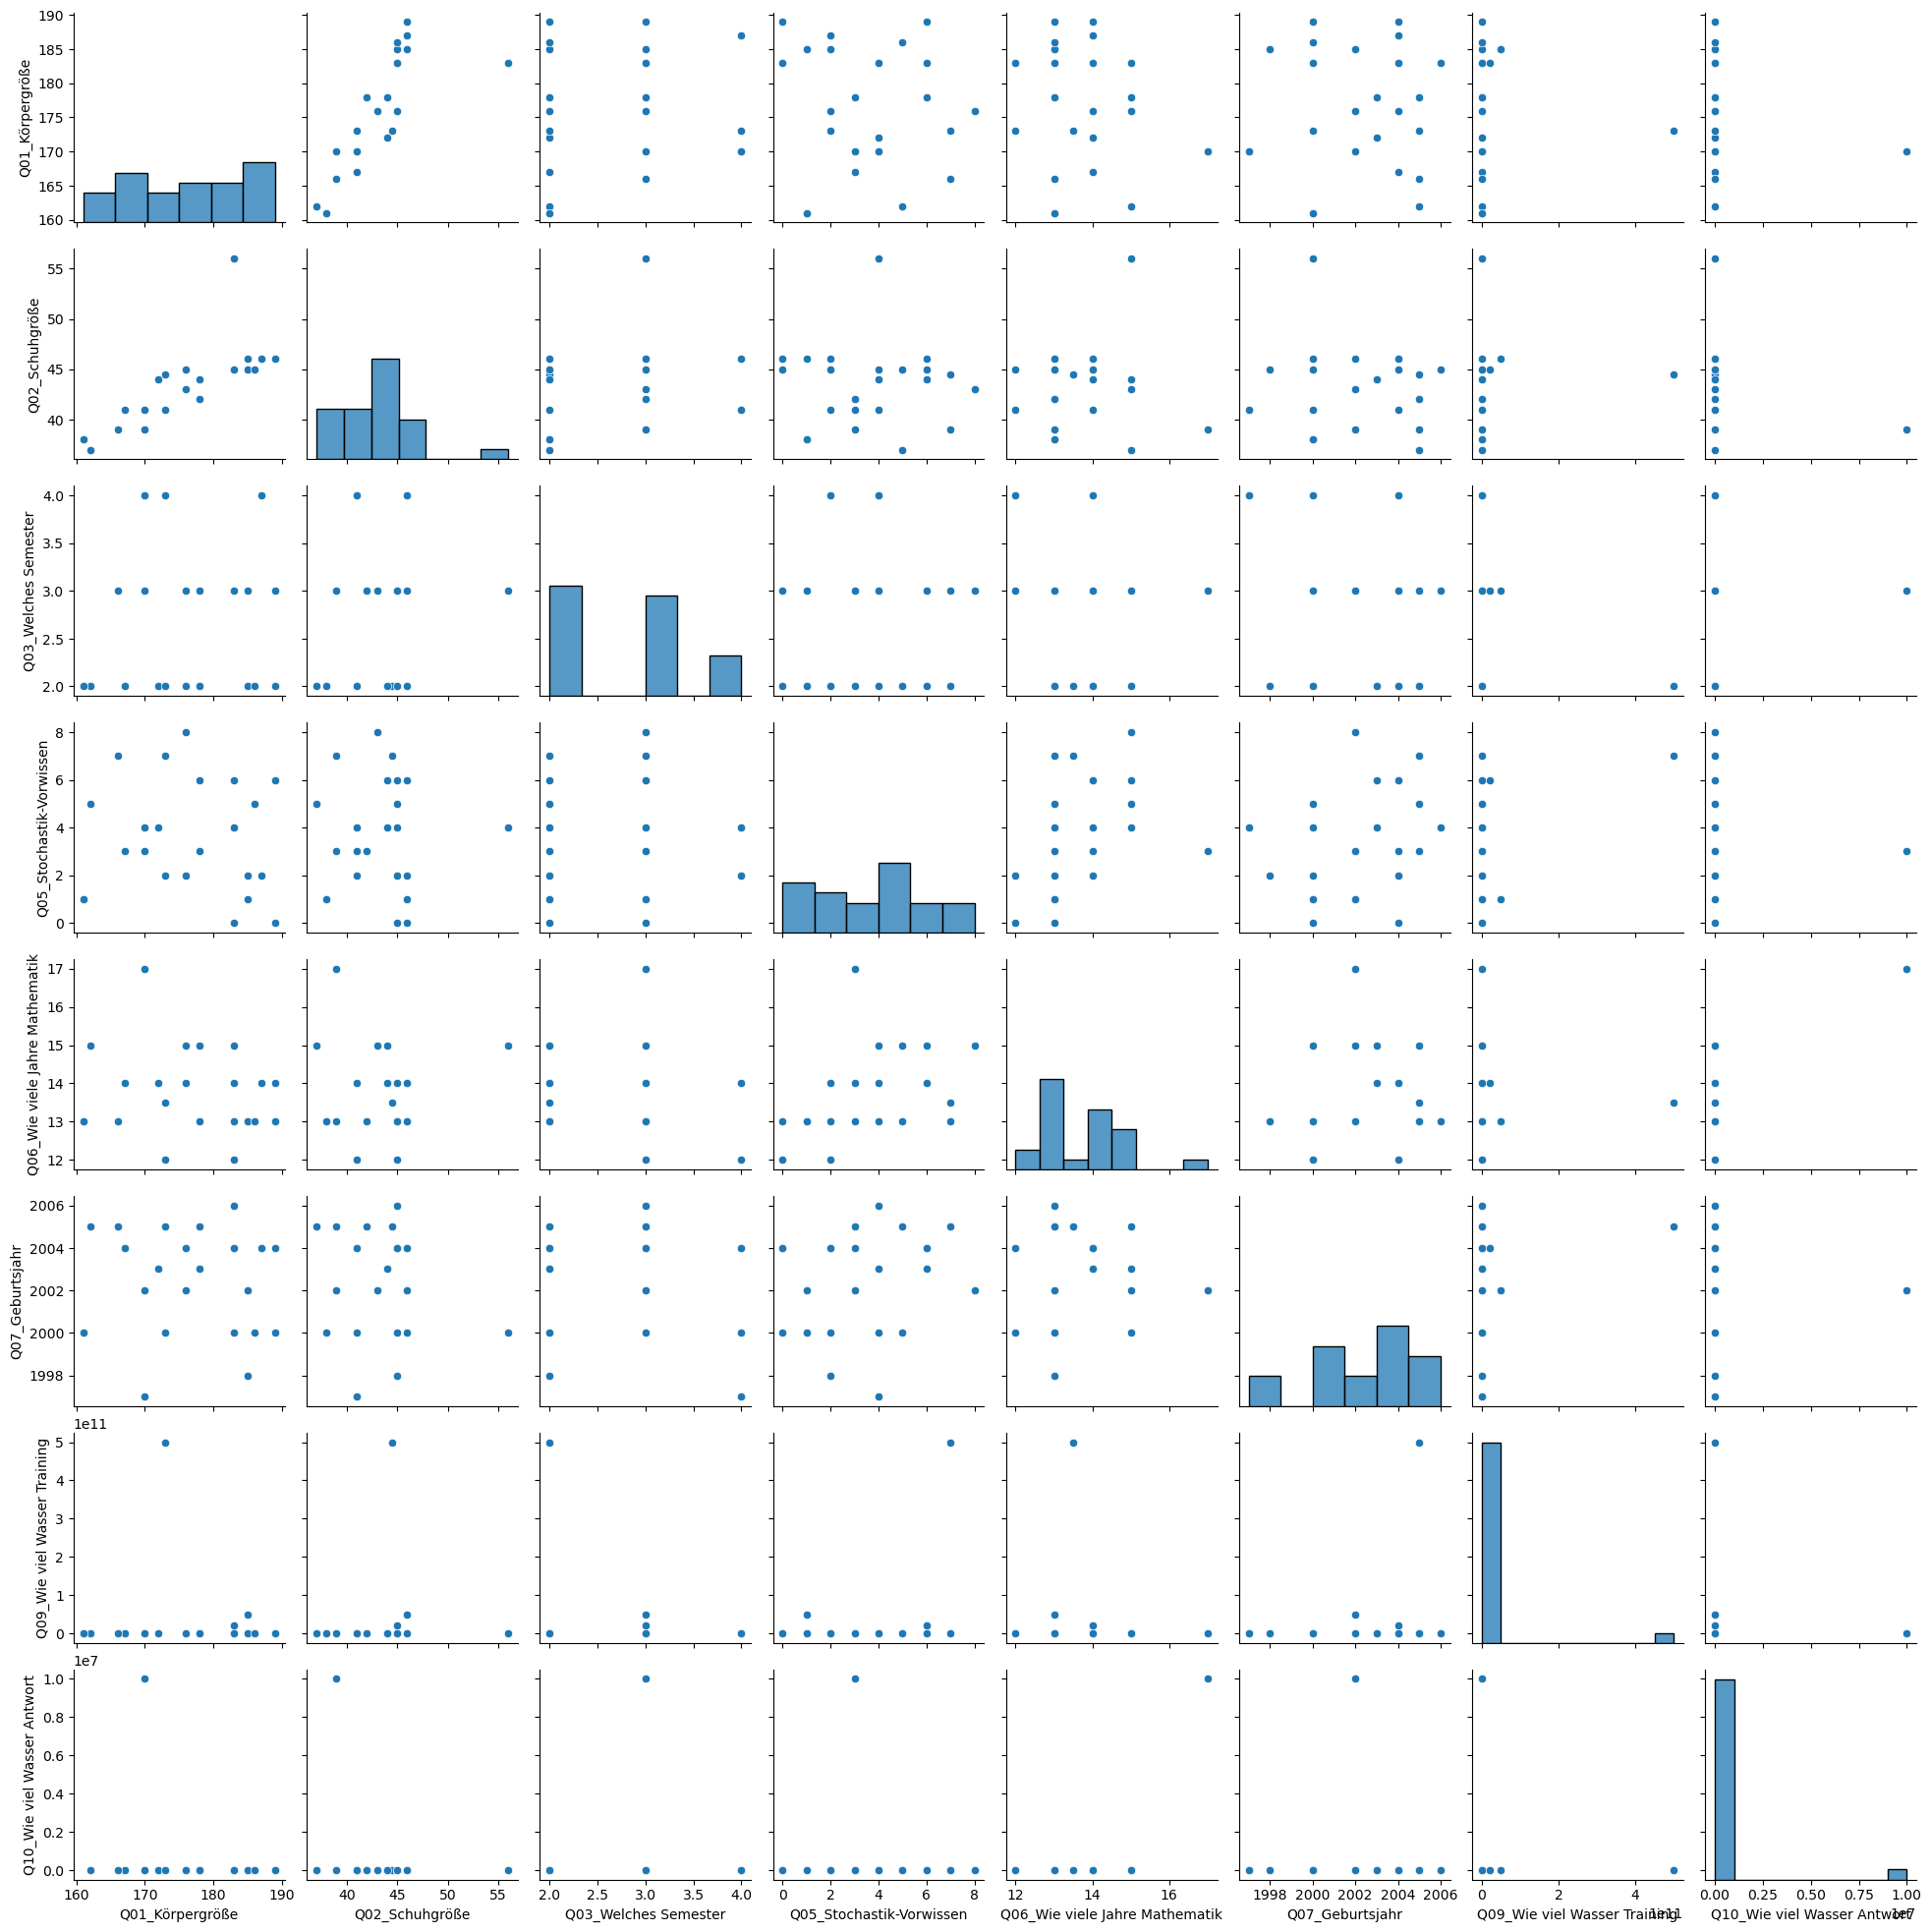

In [20]:
# und noch die Kombinationen aller möglichen Scatterplots (hier bedingt sinnvoll) und leicht überfordernd, aber ich wollte es Ihnen mal zeigen
sns.pairplot(numvals)

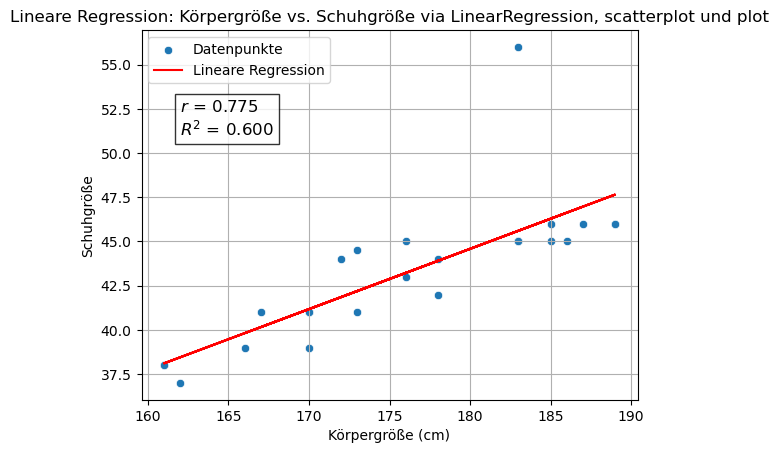

In [60]:
# Für den Schuh- und Körpergröße eine Regressionsgerade berechnen und plotten

# Methode 1: Einfache lineare Regression haendisch erstellen
from sklearn.linear_model import LinearRegression

# Lineare Regression
x = numvals[['Q01_Körpergröße']]
y = numvals['Q02_Schuhgröße']

# Korrelationskoeffizient und Bestimmtheitsmaß ausrechnen 
r = numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']].corr()
r = r.iloc[0, 1]
R2 = r**2

model_linear = LinearRegression()
model_linear.fit(x, y)
y_pred_linear = model_linear.predict(x)

sns.scatterplot(x='Q01_Körpergröße', y='Q02_Schuhgröße', data=numvals, label='Datenpunkte')
plt.plot(numvals['Q01_Körpergröße'], y_pred_linear, color='red', label='Lineare Regression')
plt.title('Lineare Regression: Körpergröße vs. Schuhgröße via LinearRegression, scatterplot und plot')
plt.xlabel('Körpergröße (cm)')
plt.ylabel('Schuhgröße')
plt.text(162, 51, f'$r$ = {r:.3f}\n$R^2$ = {R2:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid(True)
plt.show()


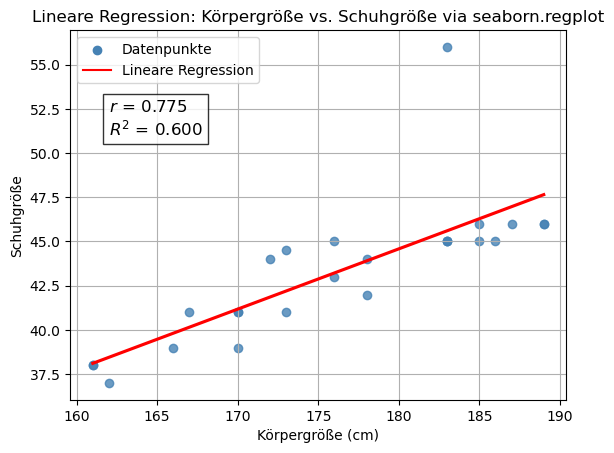

In [80]:
# Methode 2: Regression mit Seaborn (inkl. Konfidenzintervall)
ax = sns.regplot(
    x='Q01_Körpergröße',
    y='Q02_Schuhgröße',
    data=numvals,
    ci=None, # kein Konfidenzintervall
    scatter_kws={'color': 'steelblue'}, # Punkte in Blau
    line_kws={'color': 'red'}       # Linie in Rot
)
plt.grid(True)
plt.title('Lineare Regression: Körpergröße vs. Schuhgröße via seaborn.regplot')
plt.xlabel('Körpergröße (cm)')
plt.ylabel('Schuhgröße')

# Legende hinzufügen 
# haesslich, aber geht in seaborn nicht anders
ax.scatter([], [], color='steelblue', label='Datenpunkte')
ax.plot([], [], color='red', label='Lineare Regression')
ax.legend()

plt.text(162, 51, f'$r$ = {r:.3f}\n$R^2$ = {R2:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()
